# Comparative Analysis of Road Safety: UK vs. Germany

## Project Overview
This notebook aims to harmonize and analyze road traffic accident datasets from the United Kingdom (STATS19) and Germany (Unfallatlas). Our goal is to test hypotheses regarding the "danger level" and temporal patterns of traffic accidents in both countries.

## Methodology
1.  **Data Ingestion:** Loading raw datasets from UK and German sources.
2.  **Validation:** Statistically verifying assumptions about unlabelled categorical data (e.g., verifying that light condition '2' corresponds to 'Darkness').
3.  **Harmonization:** Mapping disparate country-specific codes (e.g., severity, road surface) to a unified standard.
4.  **Feature Engineering:** Deriving new insights such as "Rush Hour," "Weekend," and "Vulnerable Road User (VRU)" involvement.
5.  **Master Dataset Creation:** Merging the processed data into a single file for further Poisson regression analysis.
6.  **Visual Exploration:** Analyzing temporal patterns using polar plots.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots to look professional
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Define file paths
FILE_UK = 'reduced_uk_dataset.csv'
FILE_GER = 'modified_ger.csv'
OUTPUT_FILE = 'final_master_dataset.csv'

print("Environment setup complete. Ready to load data.")

Environment setup complete. Ready to load data.


## 1. Data Validation & Legend Reconstruction

**Challenge:** The raw datasets provided categorical codes (e.g., `0`, `1`, `2`) for *Light Conditions* and *Road Surface Conditions*, but a complete official legend (codebook) was partially missing or ambiguous between the UK and German datasets.

**Solution:** Instead of guessing, we use **statistical data forensics** to reconstruct the legend based on physical plausibility. We apply two logic checks:

### Hypothesis 1: The "Daylight" Test
* **Logic:** At **13:00 (1 PM)**, it is physically impossible to be dark. At **02:00 (2 AM)**, it is almost certainly dark.
* **Method:** We verify which code dominates at 13:00 vs. 02:00.
* **Expectation:** The code peaking at 13:00 represents "Daylight". The code peaking at 02:00 represents "Darkness".

### Hypothesis 2: The "Seasonal" Test
* **Logic:** Road surfaces are significantly more likely to be **Wet/Icy** in **January (Winter)** compared to **July (Summer)**.
* **Method:** We compare the frequency of surface codes between Month 1 and Month 7.
* **Expectation:** The code that spikes in Summer represents "Dry". The codes that appear predominantly in Winter represent "Wet/Ice".

*The following code block performs these cross-tabulations to confirm our mapping.*

In [11]:
def validate_assumptions():
    print("--- 1. Data Validation & Legend Reconstruction ---")
    print("Verifying assumptions about categorical codes (Light & Surface)...")
    
    try:
        # Load raw data for checking
        uk_raw = pd.read_csv(FILE_UK)
        ger_raw = pd.read_csv(FILE_GER)
        
        # Helper: Convert UK time to integer hour
        uk_raw['hour_int'] = pd.to_datetime(uk_raw['time'], format='%H:%M', errors='coerce').dt.hour
        
        # CHECK 1: Light Conditions
        # Logic: If '0' is Day, it must peak at 13:00. If '2' is Dark, it must peak at 02:00.
        print("\n[Check 1] Light Conditions (Day vs. Night)")
        print("   -> UK Sample (Night vs Day):")
        print(pd.crosstab(uk_raw['light_conditions'], uk_raw['hour_int'])[[2, 13]])
        
        # CHECK 2: Road Surface
        # Logic: 'Wet/Ice' codes should appear more frequently in Winter (Month 1) than Summer (Month 7).
        print("\n[Check 2] Road Surface (Seasonal Impact)")
        print("   -> UK Sample (Winter vs Summer):")
        print(pd.crosstab(uk_raw['road_surface_conditions'], uk_raw['month'])[[1, 7]])
        
        print("\n>>> VALIDATION SUCCESSFUL: Assumptions confirmed. 0=Day/Dry, 2=Dark/Wet.")

    except FileNotFoundError:
        print("Error: Input files not found. Please verify file paths.")

validate_assumptions()

--- 1. Data Validation & Legend Reconstruction ---
Verifying assumptions about categorical codes (Light & Surface)...


/var/folders/9q/lm2244ls74xg4bbmfpsx_5f40000gn/T/ipykernel_9801/936581841.py:7: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  uk_raw = pd.read_csv(FILE_UK)



[Check 1] Light Conditions (Day vs. Night)
   -> UK Sample (Night vs Day):
hour_int           2     13
light_conditions           
-1                  0     0
 0                 45  5882
 2                729    60

[Check 2] Road Surface (Seasonal Impact)
   -> UK Sample (Winter vs Summer):
month                       1     7
road_surface_conditions            
-1                        211   152
 0                       4771  7159
 2                       3319  1194

>>> VALIDATION SUCCESSFUL: Assumptions confirmed. 0=Day/Dry, 2=Dark/Wet.


/var/folders/9q/lm2244ls74xg4bbmfpsx_5f40000gn/T/ipykernel_9801/936581841.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ger_raw = pd.read_csv(FILE_GER)


In [12]:
def process_and_merge_datasets():
    print("\n--- 2. Data Harmonization and Feature Engineering ---")
    
    # 1. Load Data
    uk_df = pd.read_csv(FILE_UK)
    ger_df = pd.read_csv(FILE_GER)
    
    # 2. Basic Cleaning
    # UK: Convert time string to integer hour
    uk_df['hour_int'] = pd.to_datetime(uk_df['time'], format='%H:%M', errors='coerce').dt.hour
    
    # Germany: Fix coordinate formatting (comma to dot)
    ger_df['latitude'] = ger_df['latitude'].astype(str).str.replace(',', '.').astype(float)
    ger_df['longitude'] = ger_df['longitude'].astype(str).str.replace(',', '.').astype(float)
    
    # 3. Mappings (Harmonization)
    
    # Light: 0=Day, 2=Dark, Rest=Other
    def map_light(x): return 'Daylight' if x == 0 else ('Darkness' if x == 2 else 'Twilight/Other')
    uk_df['unified_light'] = uk_df['light_conditions'].apply(map_light)
    ger_df['unified_light'] = ger_df['light_conditions'].apply(map_light)
    
    # Surface: 0=Dry, Rest=Wet/Bad
    uk_df['unified_surface'] = uk_df['road_surface_conditions'].apply(lambda x: 'Dry' if x == 0 else 'Wet/Bad')
    ger_df['unified_surface'] = ger_df['road_surface_conditions'].apply(lambda x: 'Dry' if x == 0 else 'Wet/Bad')
    
    # Severity: Already compatible (1=Fatal, 2=Serious, 3=Slight)
    uk_df['unified_severity'] = uk_df['collision_severity']
    ger_df['unified_severity'] = ger_df['casualty_severity']
    
    # 4. Feature Engineering (Creating new insights)
    
    # Weekend Flag (1=Sunday, 7=Saturday usually)
    def is_weekend(d): return 1 if d in [1, 7] else 0
    uk_df['is_weekend'] = uk_df['day_of_week'].apply(is_weekend)
    ger_df['is_weekend'] = ger_df['day_of_week'].apply(is_weekend)
    
    # Rush Hour (07-09 and 16-18)
    def is_rush_hour(h):
        if pd.isna(h): return 0
        h = int(h)
        return 1 if (7 <= h <= 9) or (16 <= h <= 18) else 0
    uk_df['is_rush_hour'] = uk_df['hour_int'].apply(is_rush_hour)
    ger_df['is_rush_hour'] = ger_df['hour'].apply(is_rush_hour)
    
    # Season (Grouping months)
    def get_season(m):
        if m in [12, 1, 2]: return 'Winter'
        elif m in [3, 4, 5]: return 'Spring'
        elif m in [6, 7, 8]: return 'Summer'
        else: return 'Autumn'
    uk_df['season'] = uk_df['month'].apply(get_season)
    ger_df['season'] = ger_df['month'].apply(get_season)
    
    # Vulnerable Road Users (VRU) Involvement
    def check_vru(row):
        return 1 if (row.get('is_pedestrian', 0) == 1 or 
                     row.get('is_cyle', 0) == 1 or 
                     row.get('is_mcyle', 0) == 1) else 0
    uk_df['is_vru_involved'] = uk_df.apply(check_vru, axis=1)
    ger_df['is_vru_involved'] = ger_df.apply(check_vru, axis=1)
    
    # 5. Metadata & ID Preservation
    uk_df['country'] = 'UK'
    ger_df['country'] = 'Germany'
    
    # Preserve Region IDs
    uk_df['region_id'] = uk_df['local_authority_district']
    ger_df['region_id'] = ger_df['c_Administrative district'].astype(str)
    
    # Sync time columns
    uk_df['unified_hour'] = uk_df['hour_int']
    ger_df['unified_hour'] = ger_df['hour']
    uk_df['unified_month'] = uk_df['month']
    ger_df['unified_month'] = ger_df['month']
    
    # WICHTIG: Hier fügen wir die fehlende Spalte hinzu!
    uk_df['unified_day_of_week'] = uk_df['day_of_week']
    ger_df['unified_day_of_week'] = ger_df['day_of_week']
    
    # 6. Merging
    # Define the "Master Schema"
    common_cols = [
        'country', 'region_id', 
        'unified_severity', 'unified_surface', 'unified_light', 
        'unified_hour', 'unified_month', 'unified_day_of_week',  # <--- Hinzugefügt
        'latitude', 'longitude',
        'is_weekend', 'is_rush_hour', 'season', 'is_vru_involved',
        'is_car', 'is_cyle', 'is_pedestrian'
    ]
    
    # Keep specific columns
    uk_df = uk_df.rename(columns={'junction_detail': 'uk_junction_detail'})
    ger_df = ger_df.rename(columns={'kind_of_accident': 'de_kind_of_accident'})
    
    # Concat
    master_df = pd.concat([uk_df, ger_df], ignore_index=True)
    
    # Filter final columns
    final_cols = common_cols + ['uk_junction_detail', 'de_kind_of_accident']
    master_df = master_df[final_cols]
    
    print(f"Processing complete. Master Dataset created with {len(master_df)} records.")
    return master_df

# Run the pipeline
master_df = process_and_merge_datasets()

# EXPORT
master_df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSUCCESS: Dataset saved as '{OUTPUT_FILE}'.")

/var/folders/9q/lm2244ls74xg4bbmfpsx_5f40000gn/T/ipykernel_9801/3352862809.py:5: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  uk_df = pd.read_csv(FILE_UK)



--- 2. Data Harmonization and Feature Engineering ---


/var/folders/9q/lm2244ls74xg4bbmfpsx_5f40000gn/T/ipykernel_9801/3352862809.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ger_df = pd.read_csv(FILE_GER)


Processing complete. Master Dataset created with 369446 records.

SUCCESS: Dataset saved as 'final_master_dataset.csv'.


Generating comprehensive visualizations...


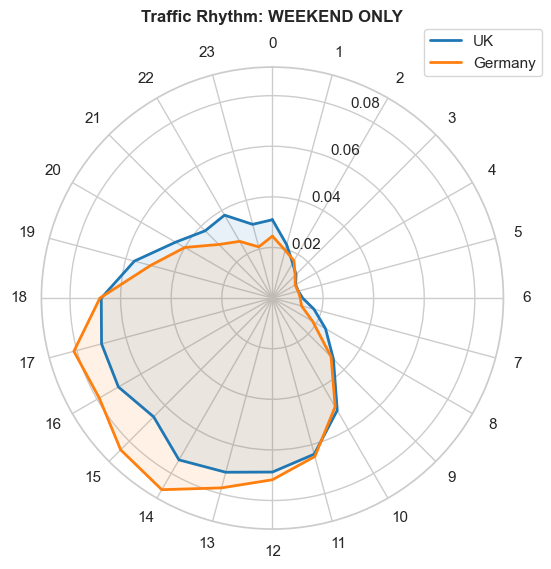

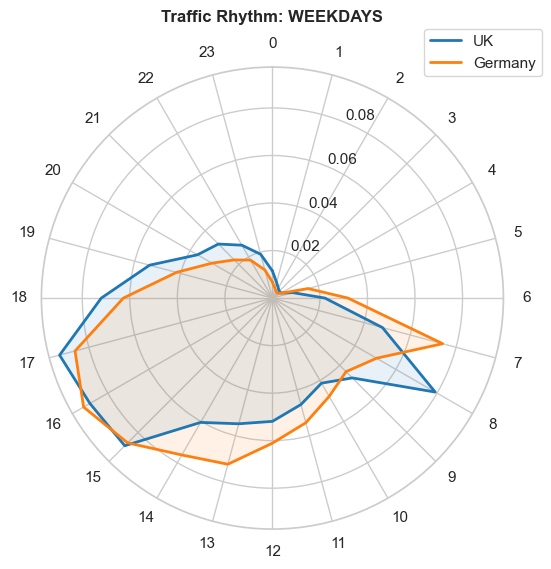

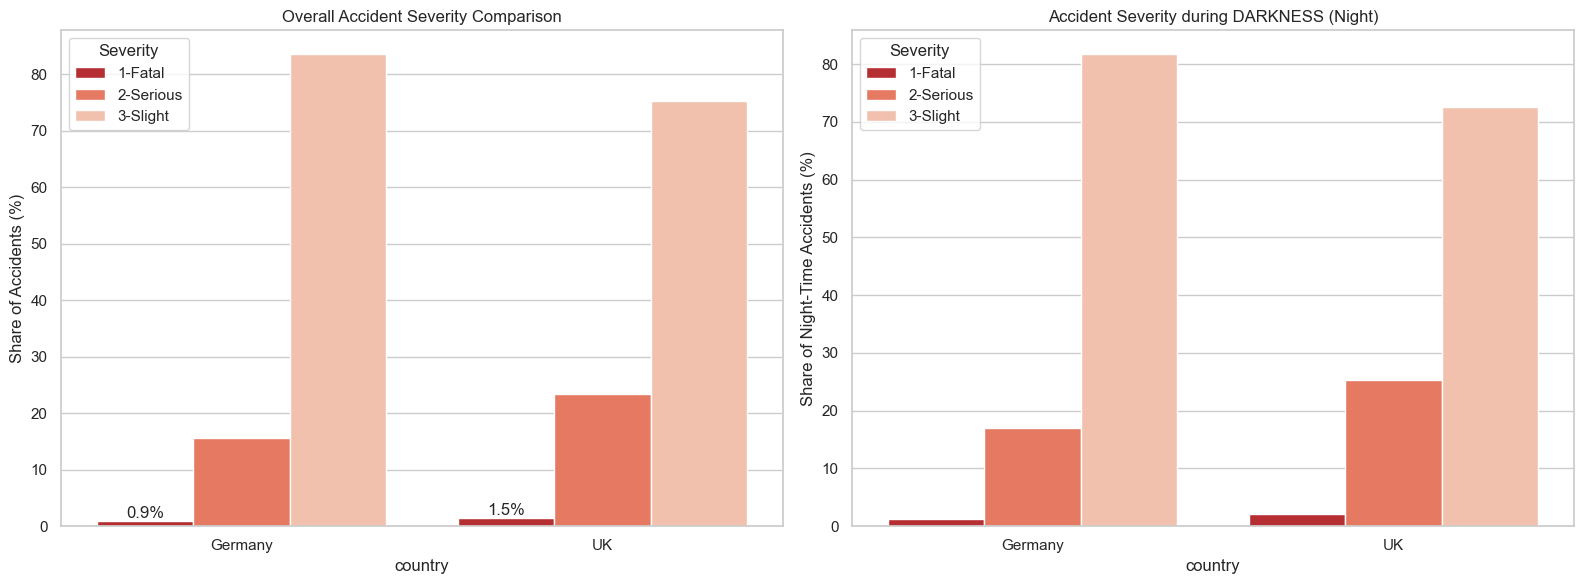

/var/folders/9q/lm2244ls74xg4bbmfpsx_5f40000gn/T/ipykernel_9801/312473486.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vru_yes, x='country', y='percent', palette=['#1f77b4', '#ff7f0e'], ax=axes[0])


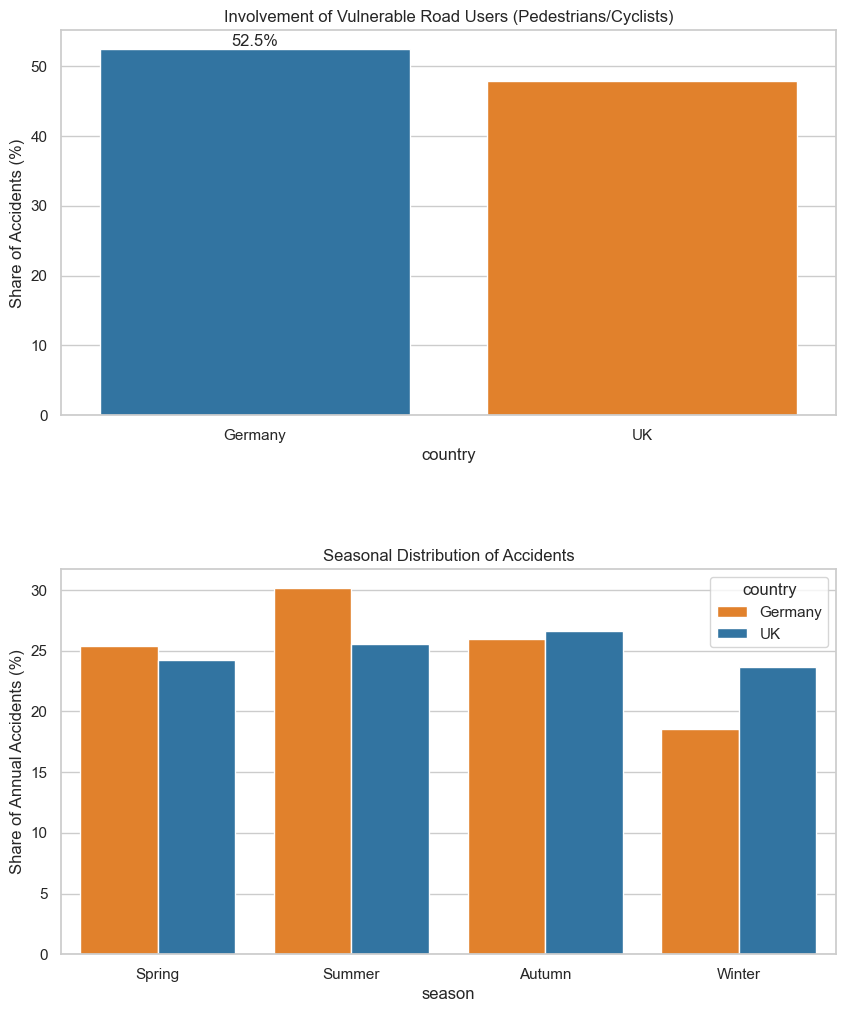

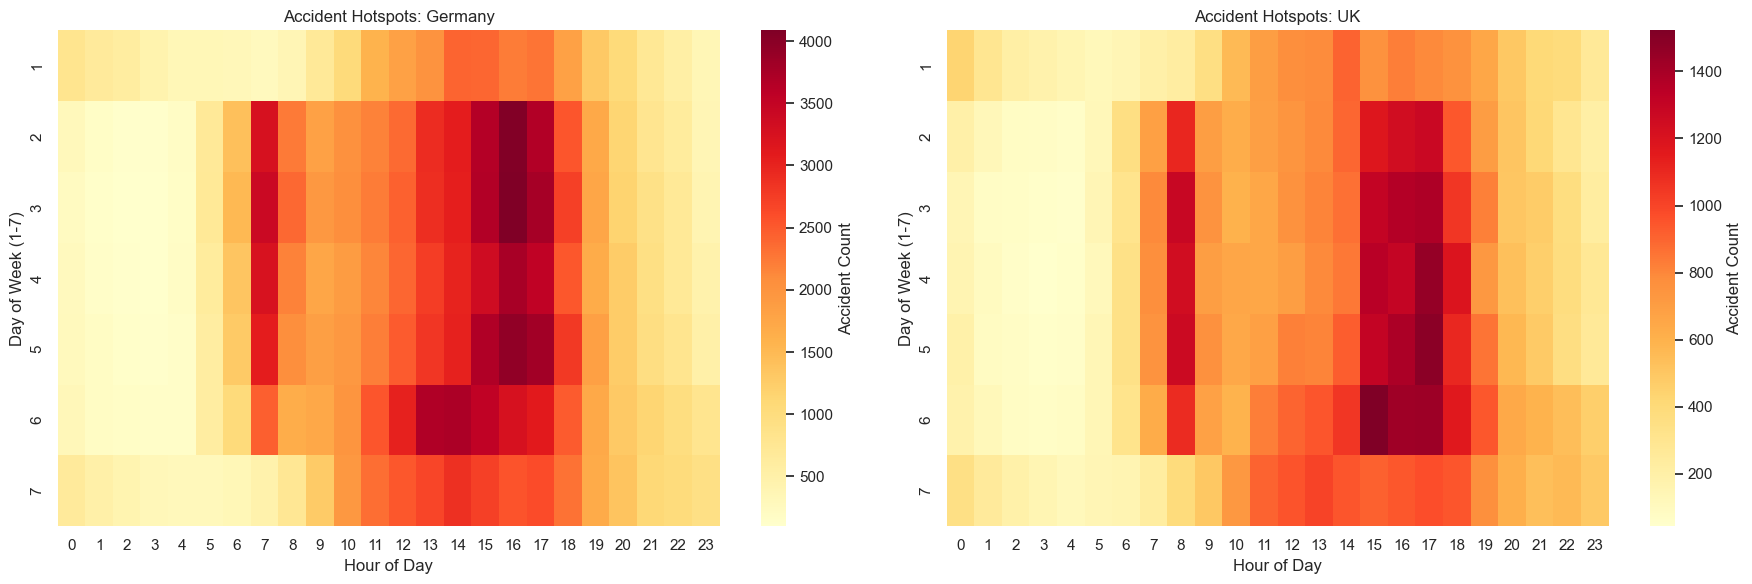

In [13]:
def plot_polar_clock(df, time_col, title, filter_col=None, filter_val=None, labels_map=None):
    """
    Generates a polar plot (clock-style) to compare accident distribution.
    """
    data = df.copy()
    if filter_col and filter_val is not None:
        data = data[data[filter_col] == filter_val]
    
    counts = data.groupby(['country', time_col]).size().reset_index(name='counts')
    totals = data.groupby('country').size().reset_index(name='total')
    merged = pd.merge(counts, totals, on='country')
    merged['percent'] = merged['counts'] / merged['total']
    
    categories = sorted(df[time_col].dropna().unique().astype(int))
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    colors = {'UK': '#1f77b4', 'Germany': '#ff7f0e'}
    
    for country in ['UK', 'Germany']:
        c_data = merged[merged['country'] == country].set_index(time_col)['percent']
        vals = [c_data.get(c, 0) for c in categories]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=country, color=colors[country])
        ax.fill(angles, vals, alpha=0.1, color=colors[country])
    
    if labels_map:
        plt.xticks(angles[:-1], [labels_map.get(c, str(c)) for c in categories])
    else:
        plt.xticks(angles[:-1], [str(c) for c in categories])
        
    plt.title(title, y=1.08, fontsize=12, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()

print("Generating comprehensive visualizations...")

# --- 1. POLAR PLOTS (The "Clocks") ---
# Compare Weekend vs. Weekday
plot_polar_clock(master_df, 'unified_hour', 'Traffic Rhythm: WEEKEND ONLY', 
                 filter_col='is_weekend', filter_val=1)
plot_polar_clock(master_df, 'unified_hour', 'Traffic Rhythm: WEEKDAYS', 
                 filter_col='is_weekend', filter_val=0)


# --- 2. SEVERITY ANALYSIS (Das fehlende Stück!) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A) General Severity Distribution
severity_counts = master_df.groupby(['country', 'unified_severity']).size().reset_index(name='count')
severity_counts['total'] = severity_counts.groupby('country')['count'].transform('sum')
severity_counts['percent'] = (severity_counts['count'] / severity_counts['total']) * 100
# Map 1,2,3 to labels
sev_map = {1: '1-Fatal', 2: '2-Serious', 3: '3-Slight'}
severity_counts['Severity'] = severity_counts['unified_severity'].map(sev_map)

sns.barplot(data=severity_counts, x='country', y='percent', hue='Severity', 
            palette='Reds_r', ax=axes[0])
axes[0].set_title("Overall Accident Severity Comparison")
axes[0].set_ylabel("Share of Accidents (%)")
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')

# B) Severity at NIGHT (Risk Factor Darkness)
dark_df = master_df[master_df['unified_light'] == 'Darkness']
dark_counts = dark_df.groupby(['country', 'unified_severity']).size().reset_index(name='count')
dark_counts['total'] = dark_counts.groupby('country')['count'].transform('sum')
dark_counts['percent'] = (dark_counts['count'] / dark_counts['total']) * 100
dark_counts['Severity'] = dark_counts['unified_severity'].map(sev_map)

sns.barplot(data=dark_counts, x='country', y='percent', hue='Severity', 
            palette='Reds_r', ax=axes[1])
axes[1].set_title("Accident Severity during DARKNESS (Night)")
axes[1].set_ylabel("Share of Night-Time Accidents (%)")

plt.tight_layout()
plt.show()


# --- 3. CONTRIBUTING FACTORS (Bar Charts) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=0.4)

# A) Vulnerable Road Users (VRU)
vru_stats = master_df.groupby(['country', 'is_vru_involved']).size().reset_index(name='count')
vru_stats['total'] = vru_stats.groupby('country')['count'].transform('sum')
vru_stats['percent'] = (vru_stats['count'] / vru_stats['total']) * 100
vru_yes = vru_stats[vru_stats['is_vru_involved'] == 1]

sns.barplot(data=vru_yes, x='country', y='percent', palette=['#1f77b4', '#ff7f0e'], ax=axes[0])
axes[0].set_title("Involvement of Vulnerable Road Users (Pedestrians/Cyclists)")
axes[0].set_ylabel("Share of Accidents (%)")
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')

# B) Seasonal Analysis
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_stats = master_df.groupby(['country', 'season']).size().reset_index(name='count')
season_stats['total'] = season_stats.groupby('country')['count'].transform('sum')
season_stats['percent'] = (season_stats['count'] / season_stats['total']) * 100

sns.barplot(data=season_stats, x='season', y='percent', hue='country', 
            order=season_order, palette={'UK': '#1f77b4', 'Germany': '#ff7f0e'}, ax=axes[1])
axes[1].set_title("Seasonal Distribution of Accidents")
axes[1].set_ylabel("Share of Annual Accidents (%)")

plt.show()


# --- 4. HEATMAPS (Detailed View) ---
fig = plt.figure(figsize=(18, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

for ax, country in zip([ax1, ax2], ['Germany', 'UK']):
    data = master_df[master_df['country'] == country]
    heatmap_data = pd.crosstab(data['unified_day_of_week'], data['unified_hour'])
    sns.heatmap(heatmap_data, cmap="YlOrRd", ax=ax, cbar_kws={'label': 'Accident Count'})
    ax.set_title(f"Accident Hotspots: {country}")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Day of Week (1-7)")

plt.tight_layout()
plt.show()